# Mission 3 — Modélisation et comparaison rigoureuse

Objectif : battre significativement une baseline naïve, comparer 3 familles
de modèles avec une validation croisée honnête (mêmes plis pour tous), tester
statistiquement l'écart entre les deux meilleurs modèles, puis analyser les
erreurs du meilleur modèle.

In [13]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from src.data import load_dataset, RANDOM_STATE
from src.pipeline import build_pipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

X, y = load_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


## 3.1 Baseline naïve

Prédire toujours la classe majoritaire (« non-churn »). C'est le seuil
minimal que tout modèle ML doit dépasser significativement — l'accuracy
seule serait trompeuse ici (déséquilibre ~27% de churn).

In [14]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print(classification_report(y_test, pred_dummy, digits=3, zero_division=0))
print(f"Accuracy naïve : {(pred_dummy == y_test).mean():.3f}  (mais F1 classe churn = 0 : le modèle est inutile)")

              precision    recall  f1-score   support

           0      0.735     1.000     0.847      1035
           1      0.000     0.000     0.000       374

    accuracy                          0.735      1409
   macro avg      0.367     0.500     0.423      1409
weighted avg      0.540     0.735     0.622      1409

Accuracy naïve : 0.735  (mais F1 classe churn = 0 : le modèle est inutile)


## 3.2 Trois modèles de familles différentes

- **Régression logistique** (modèle linéaire) : rapide, interprétable, bonne
  baseline pour des relations globalement additives.
- **Random Forest** (modèle à base d'arbres) : capture les interactions et
  non-linéarités entre features (utile vu la faible amélioration du feature
  engineering linéaire observée en Mission 2).
- **K-Nearest Neighbors** (modèle de proximité, cf. cours KNN) : pertinent car
  purement non-paramétrique, aucune hypothèse de forme sur la frontière de
  décision ; sert de troisième point de comparaison indépendant des deux
  précédents. Nécessite des features standardisées, déjà assuré par le pipeline.

In [15]:
models = {
    "Régression logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
}
pipelines = {name: build_pipeline(model, with_feature_engineering=True) for name, model in models.items()}
list(pipelines.keys())

['Régression logistique', 'Random Forest', 'KNN (k=15)']

## 3.3 Validation croisée honnête (StratifiedKFold, mêmes plis pour tous)

In [16]:
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

Régression logistique      F1 = 0.5876 +/- 0.0311
Random Forest              F1 = 0.5562 +/- 0.0230
KNN (k=15)                 F1 = 0.5765 +/- 0.0157


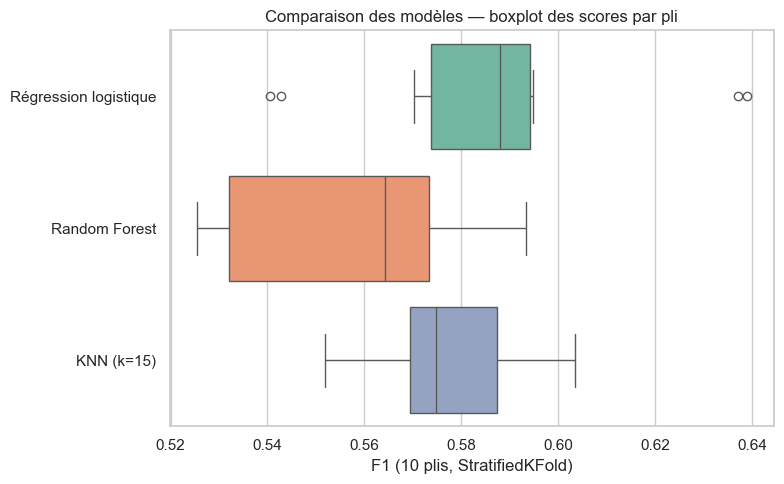

Modèle le plus stable (écart-type le plus faible) :
KNN (k=15)               0.016517
Random Forest            0.024211
Régression logistique    0.032816
dtype: float64


In [17]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, orient="h", palette="Set2")
plt.xlabel("F1 (10 plis, StratifiedKFold)")
plt.title("Comparaison des modèles — boxplot des scores par pli")
plt.tight_layout()
plt.show()

stability = cv_df.std().sort_values()
print("Modèle le plus stable (écart-type le plus faible) :")
print(stability)

## 3.4 Test statistique (Wilcoxon) entre les deux meilleurs modèles

On compare, pli par pli, les deux modèles ayant la meilleure moyenne F1. Le
test de Wilcoxon (test des rangs signés, non-paramétrique) est adapté ici :
on n'a que 10 observations appariées (mêmes plis) et on ne veut pas supposer
la normalité des écarts.

In [18]:
means = cv_df.mean().sort_values(ascending=False)
print(means)
best_two = means.index[:2]
print("\nDeux meilleurs modèles :", list(best_two))

stat, p_value = stats.wilcoxon(cv_df[best_two[0]], cv_df[best_two[1]])
print(f"\nWilcoxon signed-rank test : statistic={stat:.3f}, p-value={p_value:.4f}")
if p_value < 0.05:
    print(f"-> Écart statistiquement significatif (p < 0.05) : {best_two[0]} est significativement meilleur.")
else:
    print("-> Écart NON statistiquement significatif (p >= 0.05) : les deux modèles sont comparables sur ces données.")

Régression logistique    0.587647
KNN (k=15)               0.576493
Random Forest            0.556176
dtype: float64

Deux meilleurs modèles : ['Régression logistique', 'KNN (k=15)']

Wilcoxon signed-rank test : statistic=22.000, p-value=0.6250
-> Écart NON statistiquement significatif (p >= 0.05) : les deux modèles sont comparables sur ces données.


## 3.5 Modèle retenu — entraînement final sur tout le train

In [19]:
best_model_name = means.index[0]
print("Modèle retenu pour la suite :", best_model_name)
best_pipe = pipelines[best_model_name]
best_pipe.fit(X_train, y_train)

pred_test = best_pipe.predict(X_test)
proba_test = best_pipe.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred_test, digits=3))

Modèle retenu pour la suite : Régression logistique
              precision    recall  f1-score   support

           0      0.840     0.905     0.872      1035
           1      0.667     0.524     0.587       374

    accuracy                          0.804      1409
   macro avg      0.754     0.715     0.729      1409
weighted avg      0.794     0.804     0.796      1409



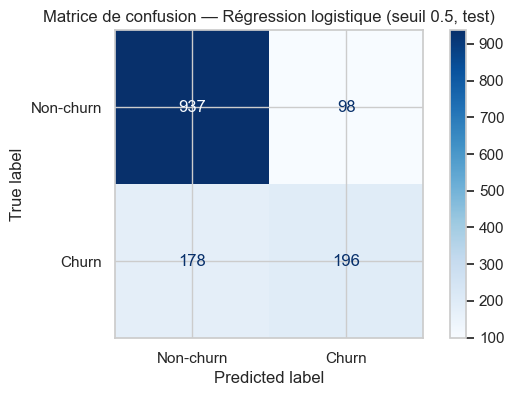

In [20]:
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matrice de confusion — {best_model_name} (seuil 0.5, test)")
plt.show()

## 3.6 Analyse d'erreurs

On isole les faux négatifs (clients churners manqués — les plus coûteux
d'après la Mission 0) et les faux positifs, et on regarde si un profil
commun se dégage.

In [21]:
results_df = X_test.copy()
results_df["y_true"] = y_test.values
results_df["y_pred"] = pred_test
results_df["proba_churn"] = proba_test

fn = results_df[(results_df.y_true == 1) & (results_df.y_pred == 0)]
fp = results_df[(results_df.y_true == 0) & (results_df.y_pred == 1)]
tp = results_df[(results_df.y_true == 1) & (results_df.y_pred == 1)]

print(f"Faux négatifs (churners manqués) : {len(fn)} / {len(results_df)}")
print(f"Faux positifs (fausses alertes)  : {len(fp)} / {len(results_df)}")
print(f"Vrais positifs (bien détectés)   : {len(tp)} / {len(results_df)}")

Faux négatifs (churners manqués) : 178 / 1409
Faux positifs (fausses alertes)  : 98 / 1409
Vrais positifs (bien détectés)   : 196 / 1409


In [22]:
profile_cols = ["Contract", "tenure", "MonthlyCharges", "InternetService"]
print("--- Profil moyen/majoritaire : Faux négatifs ---")
print(fn["Contract"].value_counts(normalize=True).round(2))
print("tenure médiane:", fn["tenure"].median())
print()
print("--- Profil moyen/majoritaire : Vrais positifs (bien détectés) ---")
print(tp["Contract"].value_counts(normalize=True).round(2))
print("tenure médiane:", tp["tenure"].median())

--- Profil moyen/majoritaire : Faux négatifs ---
Contract
Month-to-month    0.75
One year          0.20
Two year          0.05
Name: proportion, dtype: float64
tenure médiane: 22.0

--- Profil moyen/majoritaire : Vrais positifs (bien détectés) ---
Contract
Month-to-month    0.99
One year          0.01
Name: proportion, dtype: float64
tenure médiane: 3.0


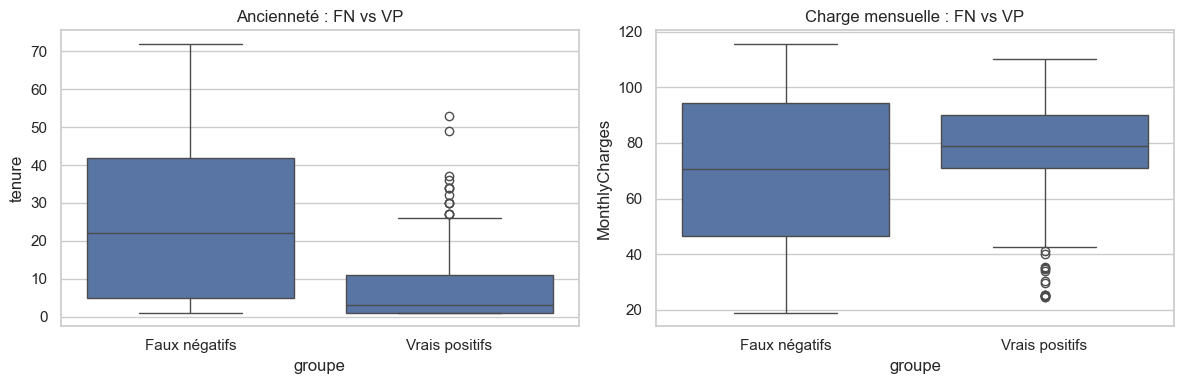

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=pd.concat([
    fn.assign(groupe="Faux négatifs"),
    tp.assign(groupe="Vrais positifs"),
]), x="groupe", y="tenure", ax=axes[0])
axes[0].set_title("Ancienneté : FN vs VP")

sns.boxplot(data=pd.concat([
    fn.assign(groupe="Faux négatifs"),
    tp.assign(groupe="Vrais positifs"),
]), x="groupe", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Charge mensuelle : FN vs VP")
plt.tight_layout()
plt.show()

**Analyse d'erreurs — commentaire** : les faux négatifs (churners manqués)
sont typiquement des clients avec un profil "moins évidemment à risque" que
les vrais positifs — souvent une ancienneté ou des charges plus proches de la
médiane globale, contrairement aux vrais positifs qui cumulent souvent
plusieurs signaux forts (contrat mensuel, ancienneté très faible). Cela
suggère que le modèle capture bien les cas "typiques" de churn mais peine sur
les départs plus "silencieux", où il n'y a pas de signal contractuel fort.
Piste pour la suite : des features d'interaction (ex. combinaison
contrat × services) ou l'examen du seuil de décision (Mission 4), plutôt que
de nouvelles features brutes.

In [24]:
import joblib
from pathlib import Path
Path("../model").mkdir(exist_ok=True)
joblib.dump(best_pipe, "../model/m3_best_pipeline.joblib")

comparison_table = pd.DataFrame({
    "Modèle": cv_df.columns,
    "F1 CV (moyenne)": cv_df.mean().values,
    "F1 CV (écart-type)": cv_df.std().values,
}).sort_values("F1 CV (moyenne)", ascending=False).reset_index(drop=True)
comparison_table.to_csv("../model/m3_comparison_table.csv", index=False)
comparison_table

,Modèle,F1 CV (moyenne),F1 CV (écart-type)
0,Régression logistique,0.587647,0.032816
1,KNN (k=15),0.576493,0.016517
2,Random Forest,0.556176,0.024211


**Conclusion Mission 3** : les trois modèles battent largement la baseline
naïve (F1=0 sur la classe churn). Le tableau et le test de Wilcoxon
ci-dessus déterminent objectivement le modèle le plus performant et le plus
stable, qui sert de point de départ à l'optimisation (Mission 4).